In [9]:
# Data Manipulation and Linear Algebra
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:

# Load the dataset into a pandas DataFrame
df = pd.read_csv("cumulative.csv")

# Check the overall dimension of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape}")

# Calculate the total number of missing values (NaN) per feature
# Sorting them in descending order to prioritize which columns need imputation or dropping
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display only the features that contain missing data
print("Missing Values per Column: \n")
print(missing_values[missing_values > 0])

Dataset Shape: (9564, 50)
Missing Values per Column: 

koi_teq_err2         9564
koi_teq_err1         9564
kepler_name          7270
koi_score            1510
koi_steff_err2        483
koi_srad_err2         468
koi_srad_err1         468
koi_steff_err1        468
koi_slogg_err2        468
koi_slogg_err1        468
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_period_err1       454
koi_period_err2       454
koi_impact_err2       454
koi_impact_err1       454
koi_depth_err1        454
koi_depth_err2        454
koi_duration_err1     454
koi_duration_err2     454
koi_model_snr         363
koi_prad_err2         363
koi_srad              363
koi_slogg             363
koi_steff             363
koi_depth             363
koi_prad_err1         363
koi_prad              363
koi_teq               363
koi_impact            363
koi_tce_delivname     346
koi_tce_plnt_num      346
koi_insol             321
koi_insol_err2        321
koi_insol_err1        321
koi_kepmag              1
dtype: in

In [11]:
# Define a list of columns that provide no analytical value
# (e.g., 100% missing data or non-numeric text identifiers)
columns_to_drop = ['koi_teq_err1', 'koi_teq_err2', 'kepler_name']

# Drop the specified columns along the column axis
# 'inplace=True' ensures the original DataFrame is modified directly
df.drop(columns=columns_to_drop, inplace=True)

# Verify the operation by checking the updated dataset shape
print(f"Updated Dataset Shape: {df.shape}")

Updated Dataset Shape: (9564, 47)


In [12]:
# Identify all numeric columns in the dataset
# Categorical or text data cannot be imputed with statistical median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Fill missing values (NaN) in each numeric column with the column's median
# The median is chosen over the mean to prevent skewness from extreme sensor outliers
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Verify the imputation success by checking the maximum number of missing values left
remaining_missing = df[numeric_cols].isnull().sum().max()
print(f"Maximum missing values in any numeric column after imputation: {remaining_missing}")

Maximum missing values in any numeric column after imputation: 0


In [13]:
# Select a subset of key numerical features for our variance analysis
# koi_period: Orbital period (days)
# koi_depth: Transit depth (amount of light blocked)
# koi_prad: Planetary radius (Earth radii)
features_to_compare = ['koi_period', 'koi_depth', 'koi_prad']

# Group the dataset by the target variable and calculate the median for the selected features
# This reveals the statistical differences between confirmed planets and false positives
population_variance = df.groupby('koi_disposition')[features_to_compare].median()

print("Median Feature Values by Planet Status:\n")
print(population_variance)

Median Feature Values by Planet Status:

                 koi_period  koi_depth  koi_prad
koi_disposition                                 
CANDIDATE         13.278651     268.95      1.83
CONFIRMED         11.322697     460.20      2.17
FALSE POSITIVE     6.383157     467.90      4.41


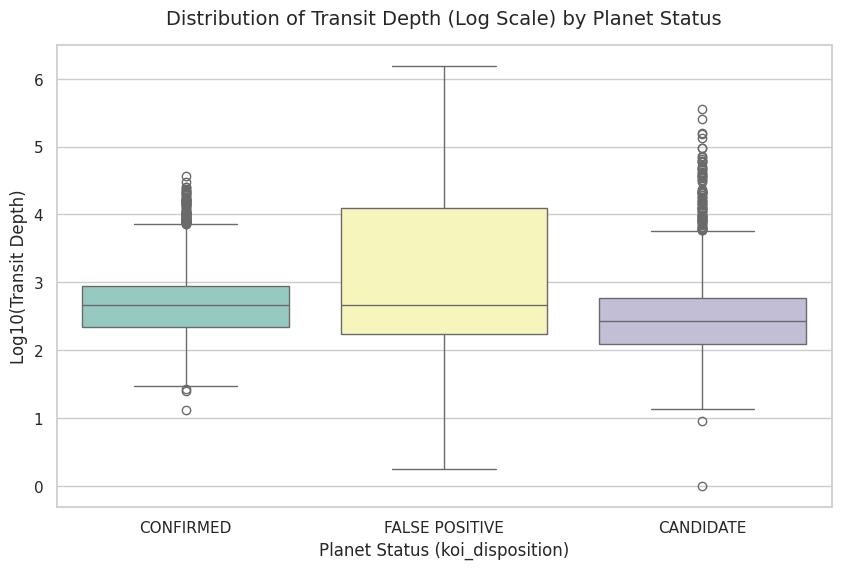

In [14]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Apply a logarithmic transformation to the koi_depth feature
# This is crucial because astronomical light dip data spans multiple orders of magnitude
# We create a temporary column for visualization purposes
df['log_koi_depth'] = np.log10(df['koi_depth'] + 1)

# Generate a boxplot to compare the distribution of transit depth across target classes
ax = sns.boxplot(x='koi_disposition',
                 y='log_koi_depth',
                 data=df,
                 hue='koi_disposition',
                 palette='Set3',
                 legend=False)

plt.title('Distribution of Transit Depth (Log Scale) by Planet Status', fontsize=14, pad=15)
plt.xlabel('Planet Status (koi_disposition)', fontsize=12)
plt.ylabel('Log10(Transit Depth)', fontsize=12)

plt.show()

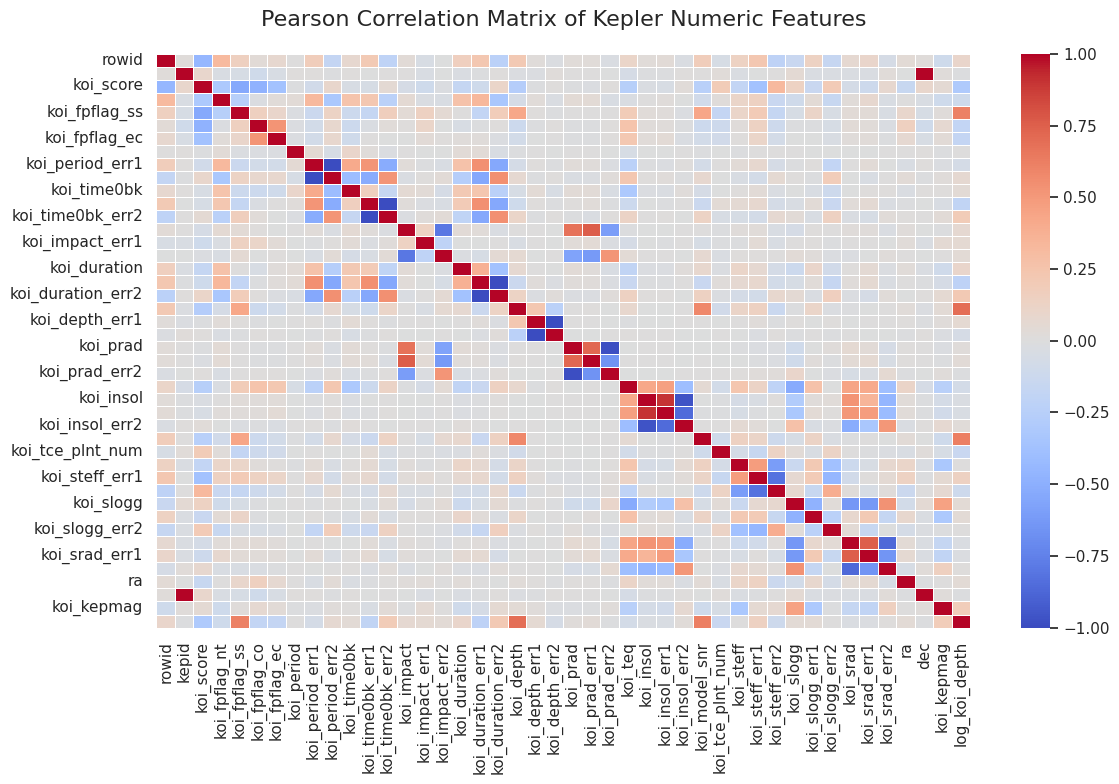

In [15]:
# CORRELATION ANALYSIS and HEATMAP

sns.set_theme(style="whitegrid")

# Select only numeric columns for correlation calculation
# Because correlation cannot be computed on categorical or text data
numeric_features = df.select_dtypes(include=['float64', 'int64'])

# Calculate the Pearson correlation matrix for numeric features
correlation_matrix = numeric_features.corr()

# Create a large figure to accommodate the heatmap clearly
plt.figure(figsize=(12, 8))

# Generate heatmap
# We turn off 'annot' (annotations) because 40+ columns would make the text unreadable
sns.heatmap(correlation_matrix,
            cmap='coolwarm',
            annot=False,
            vmin=-1,
            vmax=1,
            linewidths=0.5)


plt.title('Pearson Correlation Matrix of Kepler Numeric Features', fontsize=16, pad=20)
plt.tight_layout()

plt.show()

In [16]:
# FEATURE SELECTION and MULTICOLLINEARITY REDUCTION

# Identify all columns that contain err in their names (positive/negative error margins)
# These columns cause high multicollinearity and provide redundant information for baseline EDA
error_columns = [col for col in df.columns if 'err' in col]

# Drop the identified error margin columns from the dataset
df.drop(columns=error_columns, inplace=True)

# Verify the final structure of our cleaned and optimized dataset
print(f"Number of columns removed: {len(error_columns)}")
print(f"Final Dataset Shape: {df.shape}")

Number of columns removed: 20
Final Dataset Shape: (9564, 28)
